In [181]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [183]:
file_path = r"/content/drive/MyDrive/Final_space/Base de datos 1.csv"
tr = pd.read_csv(file_path)
tr

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,...,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,MT305_OD,0.185,0.052,NaN,NaN,NaN,NaN,0.176,0.055,NaN,...,0.056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MT306_OD,0.194,0.059,NaN,NaN,NaN,NaN,0.189,0.059,NaN,...,0.061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MT307_OD,0.194,0.053,NaN,NaN,NaN,NaN,0.192,0.057,NaN,...,0.052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MT308_OD,0.204,0.040,NaN,NaN,NaN,NaN,0.194,0.043,NaN,...,0.049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MT309_OD,0.198,0.055,NaN,NaN,NaN,NaN,0.194,0.053,NaN,...,0.059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [184]:
df = tr.copy()

In [185]:
print(df.shape)

(599, 24)


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 24 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Sample Name                                                            551 non-null    object 
 1   Baseline _Nasal_Total_Retinal_Thickness_millimeter                     491 non-null    float64
 2   Baseline _Nasal_Choroidal_Thickness_millimeter                         492 non-null    float64
 3   End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter     455 non-null    float64
 4   End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter         455 non-null    float64
 5   End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter               200 non-null    float64
 6   End_of_Recovery_Nasal_Choroidal_Thickness_millimeter                   200 non-null    flo

In [187]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 47


In [188]:
df.drop_duplicates(inplace=True)

In [189]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [190]:
df.isnull().sum()

,0
Sample Name,1
Baseline _Nasal_Total_Retinal_Thickness_millimeter,61
Baseline _Nasal_Choroidal_Thickness_millimeter,60
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,97
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,97
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,352
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,352
Baseline _Temporal_Total_Retinal_Thickness_millimeter,63
Baseline _Temporal_Choroidal_Thickness_millimeter,63
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,97


In [191]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
Unnamed: 23,100.000000
Unnamed: 22,100.000000
Unnamed: 21,100.000000
Unnamed: 19,100.000000
Unnamed: 20,100.000000
End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,63.949275
End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,63.949275
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,63.768116
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,63.768116
End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,60.326087


In [192]:
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

df = df.dropna(axis=1, how='all')

In [193]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,63.949275
End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,63.949275
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,63.768116
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,63.768116
End_of_Recovery_Linear_Choroidal_Thickness_millimeter,60.326087
End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,60.326087
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,17.934783
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,17.572464
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,17.572464
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,17.572464


In [194]:
columnas_problema = [
    'End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter',
    'End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter'
]
for col in columnas_problema:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [195]:
columnas_numericas = df.select_dtypes(include="number").columns

print(columnas_numericas)

Index(['Baseline _Nasal_Total_Retinal_Thickness_millimeter',
       'Baseline _Nasal_Choroidal_Thickness_millimeter',
       'End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter',
       'End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter',
       'End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter',
       'End_of_Recovery_Nasal_Choroidal_Thickness_millimeter',
       'Baseline _Temporal_Total_Retinal_Thickness_millimeter',
       'Baseline _Temporal_Choroidal_Thickness_millimeter',
       'End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter',
       'End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter',
       'End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter',
       'End_of_Recovery_Temporal_Choroidal_Thickness_millimeter',
       'Baseline _Linear_Total_Retinal_Thickness_millimeter',
       'Baseline _Linear_Choroidal_Thickness_millimeter',
       'End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_m

In [196]:
for col in columnas_numericas:
    negativos = (df[col] < 0).sum()

    if negativos > 0:
        print(col, ":", negativos)

In [197]:
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Baseline _Nasal_Total_Retinal_Thickness_millimeter,491.0,0.200430,0.012612,0.1720,0.192,0.1980,0.211,0.235
Baseline _Nasal_Choroidal_Thickness_millimeter,492.0,0.051732,0.036357,0.0340,0.046,0.0490,0.052,0.560
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,455.0,0.192306,0.013831,0.0193,0.188,0.1930,0.198,0.241
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,455.0,0.050651,0.034054,0.0360,0.045,0.0470,0.050,0.480
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,200.0,0.191069,0.017688,0.0187,0.186,0.1920,0.197,0.223
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,200.0,0.049690,0.010614,0.0360,0.046,0.0480,0.053,0.179
Baseline _Temporal_Total_Retinal_Thickness_millimeter,489.0,0.199892,0.014367,0.0220,0.192,0.1970,0.209,0.234
Baseline _Temporal_Choroidal_Thickness_millimeter,489.0,0.050773,0.026061,0.0360,0.046,0.0490,0.052,0.460
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,453.0,0.193813,0.036953,0.0183,0.188,0.1920,0.197,0.920
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,453.0,0.050748,0.040108,0.0330,0.044,0.0470,0.050,0.560


In [198]:
df[df["End_of_Recovery_Linear_Choroidal_Thickness_millimeter"] ==
   df["End_of_Recovery_Linear_Choroidal_Thickness_millimeter"].max()]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
485,MT217_OS,0.192,0.047,0.189,0.043,0.182,0.043,0.182,0.053,0.188,0.044,0.18,0.052,0.192,0.046,0.183,0.046,0.182,46.0


In [199]:
df[df["End_of_Recovery_Linear_Choroidal_Thickness_millimeter"] ==
   df["End_of_Recovery_Linear_Choroidal_Thickness_millimeter"].min()]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
316,FT74_OS,0.194,0.049,0.193,0.048,0.190,0.047,0.189,0.044,0.190,0.043,0.189,0.040,0.190,0.047,0.186,0.043,0.185,0.04
332,FT81_OS,0.189,0.046,NaN,NaN,0.184,0.045,0.187,0.045,NaN,NaN,0.185,0.042,0.193,0.045,0.193,0.042,0.190,0.04
464,MT246_OD,NaN,NaN,0.179,0.053,0.186,0.046,NaN,NaN,0.169,0.043,0.170,0.041,NaN,NaN,0.175,0.052,0.180,0.04
518,MT142_OS,0.217,0.045,NaN,NaN,0.188,0.047,0.212,0.047,NaN,NaN,0.185,0.049,0.216,0.057,NaN,NaN,0.182,0.04


In [200]:
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5*IQR
    limite_superior = Q3 + 1.5*IQR

    outliers = ((df[col] < limite_inferior) |
                (df[col] > limite_superior)).sum()

    print(col, "->", outliers)

Baseline _Nasal_Total_Retinal_Thickness_millimeter -> 0
Baseline _Nasal_Choroidal_Thickness_millimeter -> 10
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter -> 27
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter -> 25
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter -> 10
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter -> 2
Baseline _Temporal_Total_Retinal_Thickness_millimeter -> 1
Baseline _Temporal_Choroidal_Thickness_millimeter -> 11
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter -> 36
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter -> 11
End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter -> 6
End_of_Recovery_Temporal_Choroidal_Thickness_millimeter -> 6
Baseline _Linear_Total_Retinal_Thickness_millimeter -> 12
Baseline _Linear_Choroidal_Thickness_millimeter -> 9
End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter -> 18
End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_m

In [201]:
df.loc[485]

,485
Sample Name,MT217_OS
Baseline _Nasal_Total_Retinal_Thickness_millimeter,0.192
Baseline _Nasal_Choroidal_Thickness_millimeter,0.047
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,0.189
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,0.043
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,0.182
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,0.043
Baseline _Temporal_Total_Retinal_Thickness_millimeter,0.182
Baseline _Temporal_Choroidal_Thickness_millimeter,0.053
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,0.188


In [202]:
for col in df.select_dtypes(include="number").columns:
    print("\n", col)
    print("Min:", df[col].min())
    print("Max:", df[col].max())


 Baseline _Nasal_Total_Retinal_Thickness_millimeter
Min: 0.172
Max: 0.235

 Baseline _Nasal_Choroidal_Thickness_millimeter
Min: 0.034
Max: 0.56

 End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter
Min: 0.0193
Max: 0.241

 End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter
Min: 0.036
Max: 0.48

 End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter
Min: 0.0187
Max: 0.223

 End_of_Recovery_Nasal_Choroidal_Thickness_millimeter
Min: 0.036
Max: 0.179

 Baseline _Temporal_Total_Retinal_Thickness_millimeter
Min: 0.022
Max: 0.234

 Baseline _Temporal_Choroidal_Thickness_millimeter
Min: 0.036
Max: 0.46

 End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter
Min: 0.0183
Max: 0.92

 End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter
Min: 0.033
Max: 0.56

 End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter
Min: 0.0178
Max: 0.214

 End_of_Recovery_Temporal_Choroidal_Thickness_millimeter
Min: 0.034
Max: 0.47

 Baseline _Linear_T

In [203]:
df.loc[485, "End_of_Recovery_Linear_Choroidal_Thickness_millimeter"] = 0.046

In [204]:
df[df["Baseline _Nasal_Choroidal_Thickness_millimeter"] == 0.56]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
541,MT365_OD,0.2,0.56,NaN,NaN,NaN,NaN,0.192,0.055,NaN,NaN,NaN,NaN,0.197,0.052,0.179,0.061,NaN,NaN


In [205]:
df[df["Baseline _Linear_Choroidal_Thickness_millimeter"] == 0.58]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
154,MT150_OD,0.219,0.5,0.203,0.059,0.213,0.06,0.212,0.44,0.192,0.052,0.2,0.043,0.212,0.58,0.204,0.061,0.213,0.055


In [206]:
for col in df.columns:
    if "Choroidal" in col:
        sospechosos = df[df[col] > 0.15]
        if not sospechosos.empty:
            print(f"\n{col}: {len(sospechosos)} casos sospechosos")
            print(sospechosos[["Sample Name", col]])


Baseline _Nasal_Choroidal_Thickness_millimeter: 3 casos sospechosos
    Sample Name  Baseline _Nasal_Choroidal_Thickness_millimeter
154    MT150_OD                                            0.50
240     FT16_OD                                            0.47
541    MT365_OD                                            0.56

End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter: 3 casos sospechosos
    Sample Name  \
221     FT22_OS   
235     FT03_OD   
254    FT154_OD   

     End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter  
221                                               0.44               
235                                               0.48               
254                                               0.47               

End_of_Recovery_Nasal_Choroidal_Thickness_millimeter: 1 casos sospechosos
    Sample Name  End_of_Recovery_Nasal_Choroidal_Thickness_millimeter
463    MT241_OD                                              0.179   

Baseline _Tempora

In [207]:
df.loc[df["Sample Name"] == "FT37_OS",
       "End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter"] = 0.193

df.loc[df["Sample Name"] == "FT104_OD",
       "End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter"] = 0.187

df.loc[df["Sample Name"] == "MT149_OD",
       "Baseline _Temporal_Total_Retinal_Thickness_millimeter"] = 0.220

In [208]:
# Baseline Nasal
df.loc[df["Sample Name"] == "MT150_OD",
       "Baseline _Nasal_Choroidal_Thickness_millimeter"] = 0.050

df.loc[df["Sample Name"] == "FT16_OD",
       "Baseline _Nasal_Choroidal_Thickness_millimeter"] = 0.047

df.loc[df["Sample Name"] == "MT365_OD",
       "Baseline _Nasal_Choroidal_Thickness_millimeter"] = 0.056

# HU Nasal
df.loc[df["Sample Name"] == "FT22_OS",
       "End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter"] = 0.044

df.loc[df["Sample Name"] == "FT03_OD",
       "End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter"] = 0.048

df.loc[df["Sample Name"] == "FT154_OD",
       "End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter"] = 0.047

# Recovery Nasal
df.loc[df["Sample Name"] == "MT241_OD",
       "End_of_Recovery_Nasal_Choroidal_Thickness_millimeter"] = 0.0179

In [209]:
df.loc[df["Sample Name"] == "MT150_OD",
       "Baseline _Temporal_Choroidal_Thickness_millimeter"] = 0.044

df.loc[df["Sample Name"] == "FT97_OS",
       "Baseline _Temporal_Choroidal_Thickness_millimeter"] = 0.046

df.loc[df["Sample Name"] == "MT56_OD",
       "End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter"] = 0.056

df.loc[df["Sample Name"] == "MT273_OS",
       "End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter"] = 0.049

df.loc[df["Sample Name"] == "MT151_OD",
       "End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter"] = 0.056

df.loc[df["Sample Name"] == "FT78_OD",
       "End_of_Recovery_Temporal_Choroidal_Thickness_millimeter"] = 0.047

In [210]:
df.loc[df["Sample Name"] == "MT56_OD",
       "Baseline _Linear_Choroidal_Thickness_millimeter"] = 0.056

df.loc[df["Sample Name"] == "MT150_OD",
       "Baseline _Linear_Choroidal_Thickness_millimeter"] = 0.058

df.loc[df["Sample Name"] == "MT167_OS",
       "Baseline _Linear_Choroidal_Thickness_millimeter"] = 0.052

df.loc[df["Sample Name"] == "MT301_OD",
       "End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter"] = 0.194

df.loc[df["Sample Name"] == "FT35_OS",
       "End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter"] = 0.047

df.loc[df["Sample Name"] == "FT45_OD",
       "End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter"] = 0.047

df.loc[df["Sample Name"] == "MT265_OS",
       "End_of_Recovery_Linear_Choroidal_Thickness_millimeter"] = 0.047

df.loc[df["Sample Name"] == "MT217_OS",
       "End_of_Recovery_Linear_Choroidal_Thickness_millimeter"] = 0.046

In [211]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Baseline _Nasal_Total_Retinal_Thickness_millimeter,491.0,0.200430,0.012612,0.1720,0.19200,0.1980,0.211,0.235
Baseline _Nasal_Choroidal_Thickness_millimeter,492.0,0.048933,0.004726,0.0340,0.04600,0.0490,0.052,0.068
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,455.0,0.192688,0.011190,0.1020,0.18800,0.1930,0.198,0.241
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,455.0,0.047901,0.004993,0.0360,0.04450,0.0470,0.050,0.067
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,200.0,0.191910,0.012765,0.0840,0.18600,0.1920,0.197,0.223
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,200.0,0.048885,0.005750,0.0179,0.04575,0.0480,0.053,0.064
Baseline _Temporal_Total_Retinal_Thickness_millimeter,489.0,0.200297,0.011926,0.1690,0.19200,0.1970,0.209,0.234
Baseline _Temporal_Choroidal_Thickness_millimeter,489.0,0.049117,0.004790,0.0360,0.04600,0.0490,0.052,0.067
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,453.0,0.193813,0.036953,0.0183,0.18800,0.1920,0.197,0.920
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,453.0,0.047550,0.004914,0.0330,0.04400,0.0470,0.050,0.071


In [212]:
df[df["Baseline _Linear_Total_Retinal_Thickness_millimeter"] == 0.017]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
442,MT186_OD,0.192,0.05,0.175,0.05,NaN,NaN,0.186,0.041,0.173,0.047,NaN,NaN,0.017,0.052,0.175,0.045,NaN,NaN


In [213]:
df.loc[df["Sample Name"] == "MT186_OD",
       "Baseline _Linear_Total_Retinal_Thickness_millimeter"] = 0.170

In [214]:
df[df["End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter"] == 0.0178]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
266,FT98_OD,0.182,0.046,0.182,0.045,0.182,0.045,0.179,0.047,0.179,0.043,0.0178,0.044,0.192,0.05,0.188,0.049,0.188,0.049


In [215]:
df.loc[df["Sample Name"] == "FT98_OD",
       "End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter"] = 0.178

In [216]:
df[df["End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter"] == 0.044]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
145,MT301_OD,0.22,0.052,0.21,0.036,0.195,0.05,0.216,0.05,0.192,0.044,0.194,0.048,0.209,0.053,0.197,0.194,0.044,NaN


In [217]:
df.loc[df["Sample Name"] == "MT301_OD",
       "End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter"] = np.nan

In [218]:
print(df.shape)

(552, 19)


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 551
Data columns (total 19 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Sample Name                                                            551 non-null    object 
 1   Baseline _Nasal_Total_Retinal_Thickness_millimeter                     491 non-null    float64
 2   Baseline _Nasal_Choroidal_Thickness_millimeter                         492 non-null    float64
 3   End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter     455 non-null    float64
 4   End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter         455 non-null    float64
 5   End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter               200 non-null    float64
 6   End_of_Recovery_Nasal_Choroidal_Thickness_millimeter                   200 non-null    float64


In [220]:
print(df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"].dtype)
print(df["End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"].dtype)

float64
float64


In [221]:
df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"] = pd.to_numeric(
    df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"],
    errors="coerce"
)

df["End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"] = pd.to_numeric(
    df["End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"],
    errors="coerce"
)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 551
Data columns (total 19 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Sample Name                                                            551 non-null    object 
 1   Baseline _Nasal_Total_Retinal_Thickness_millimeter                     491 non-null    float64
 2   Baseline _Nasal_Choroidal_Thickness_millimeter                         492 non-null    float64
 3   End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter     455 non-null    float64
 4   End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter         455 non-null    float64
 5   End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter               200 non-null    float64
 6   End_of_Recovery_Nasal_Choroidal_Thickness_millimeter                   200 non-null    float64


In [223]:
df[df["Sample Name"].isna()]

,Sample Name,Baseline _Nasal_Total_Retinal_Thickness_millimeter,Baseline _Nasal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,Baseline _Temporal_Total_Retinal_Thickness_millimeter,Baseline _Temporal_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter,End_of_Recovery_Temporal_Choroidal_Thickness_millimeter,Baseline _Linear_Total_Retinal_Thickness_millimeter,Baseline _Linear_Choroidal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter,End_of_Hindlimb_Unloading_Linear_Choroidal_Thickness_millimeter,End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter,End_of_Recovery_Linear_Choroidal_Thickness_millimeter
551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [224]:
df = df[df["Sample Name"].notna()]

In [225]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "%": round(df.isnull().mean()*100, 2)
})

print(nulos.sort_values("%", ascending=False))

                                                    Nulos      %
End_of_Recovery_Temporal_Choroidal_Thickness_mi...    352  63.88
End_of_Recovery_Temporal_Total_Retinal_Thicknes...    352  63.88
End_of_Recovery_Nasal_Choroidal_Thickness_milli...    351  63.70
End_of_Recovery_Nasal_Total_Retinal_Thickness_m...    351  63.70
End_of_Recovery_Linear_Choroidal_Thickness_mill...    332  60.25
End_of_Recovery_Linear_Total_Retinal_Thickness_...    332  60.25
End_of_Hindlimb_Unloading_Temporal_Total_Retina...     98  17.79
End_of_Hindlimb_Unloading_Temporal_Choroidal_Th...     98  17.79
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thick...     96  17.42
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_T...     96  17.42
End_of_Hindlimb_Unloading_Linear_Choroidal_Thic...     83  15.06
End_of_Hindlimb_Unloading_Linear_Total_Retinal_...     81  14.70
Baseline _Temporal_Total_Retinal_Thickness_mill...     62  11.25
Baseline _Temporal_Choroidal_Thickness_millimeter      62  11.25
Baseline _Nasal_Total_Ret

In [226]:
for col in [
    "End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter",
    "Baseline _Linear_Total_Retinal_Thickness_millimeter",
    "End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter"
]:
    print("\n", col)
    print(df.loc[df[col] == df[col].min(), ["Sample Name", col]])


 End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter
    Sample Name  End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter
268    FT102_OD                                             0.0196          

 Baseline _Linear_Total_Retinal_Thickness_millimeter
    Sample Name  Baseline _Linear_Total_Retinal_Thickness_millimeter
185    FT216_OS                                             0.0203  

 End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter
    Sample Name  End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter
145    MT301_OD                                              0.044        


In [227]:
df[df["Sample Name"] == "FT102_OD"].T

,268
Sample Name,FT102_OD
Baseline _Nasal_Total_Retinal_Thickness_millimeter,0.191
Baseline _Nasal_Choroidal_Thickness_millimeter,0.044
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,NaN
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,NaN
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,0.188
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,0.043
Baseline _Temporal_Total_Retinal_Thickness_millimeter,0.197
Baseline _Temporal_Choroidal_Thickness_millimeter,0.047
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,NaN


In [228]:
df.loc[df["Sample Name"] == "FT102_OD",
       "End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter"] = 0.196

In [229]:
df.loc[df["Sample Name"] == "FT216_OS",
       "Baseline _Linear_Total_Retinal_Thickness_millimeter"] = 0.203

In [230]:
df.loc[df["Sample Name"] == "MT301_OD",
       "End_of_Recovery_Linear_Total_Retinal_Thickness_millimeter"] = 0.194

In [231]:
print(df[df["Sample Name"] == "FT102_OD"].T)

print(df[df["Sample Name"] == "FT216_OS"].T)

print(df[df["Sample Name"] == "MT301_OD"].T)

                                                         268
Sample Name                                         FT102_OD
Baseline _Nasal_Total_Retinal_Thickness_millimeter     0.191
Baseline _Nasal_Choroidal_Thickness_millimeter         0.044
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_T...       NaN
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thick...       NaN
End_of_Recovery_Nasal_Total_Retinal_Thickness_m...     0.188
End_of_Recovery_Nasal_Choroidal_Thickness_milli...     0.043
Baseline _Temporal_Total_Retinal_Thickness_mill...     0.197
Baseline _Temporal_Choroidal_Thickness_millimeter      0.047
End_of_Hindlimb_Unloading_Temporal_Total_Retina...       NaN
End_of_Hindlimb_Unloading_Temporal_Choroidal_Th...       NaN
End_of_Recovery_Temporal_Total_Retinal_Thicknes...     0.196
End_of_Recovery_Temporal_Choroidal_Thickness_mi...     0.047
Baseline _Linear_Total_Retinal_Thickness_millim...     0.198
Baseline _Linear_Choroidal_Thickness_millimeter         0.05
End_of_Hindlimb_Unloadin

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551 entries, 0 to 550
Data columns (total 19 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Sample Name                                                            551 non-null    object 
 1   Baseline _Nasal_Total_Retinal_Thickness_millimeter                     491 non-null    float64
 2   Baseline _Nasal_Choroidal_Thickness_millimeter                         492 non-null    float64
 3   End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter     455 non-null    float64
 4   End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter         455 non-null    float64
 5   End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter               200 non-null    float64
 6   End_of_Recovery_Nasal_Choroidal_Thickness_millimeter                   200 non-null    float64


In [233]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Baseline _Nasal_Total_Retinal_Thickness_millimeter,491.0,0.200430,0.012612,0.1720,0.19200,0.1980,0.211,0.235
Baseline _Nasal_Choroidal_Thickness_millimeter,492.0,0.048933,0.004726,0.0340,0.04600,0.0490,0.052,0.068
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,455.0,0.192688,0.011190,0.1020,0.18800,0.1930,0.198,0.241
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,455.0,0.047901,0.004993,0.0360,0.04450,0.0470,0.050,0.067
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,200.0,0.191910,0.012765,0.0840,0.18600,0.1920,0.197,0.223
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,200.0,0.048885,0.005750,0.0179,0.04575,0.0480,0.053,0.064
Baseline _Temporal_Total_Retinal_Thickness_millimeter,489.0,0.200297,0.011926,0.1690,0.19200,0.1970,0.209,0.234
Baseline _Temporal_Choroidal_Thickness_millimeter,489.0,0.049117,0.004790,0.0360,0.04600,0.0490,0.052,0.067
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,453.0,0.193813,0.036953,0.0183,0.18800,0.1920,0.197,0.920
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,453.0,0.047550,0.004914,0.0330,0.04400,0.0470,0.050,0.071


In [234]:
df.loc[
    df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"] == 0.0183,
    "End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"
] = 0.183

df.loc[
    df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"] == 0.920,
    "End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"
] = 0.192

df.loc[
    df["End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"] == 0.0187,
    "End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"
] = 0.187

df.loc[
    df["End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"] == 1.940,
    "End_of_Hindlimb_Unloading_Linear_Total_Retinal_Thickness_millimeter"
] = 0.194

In [235]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Baseline _Nasal_Total_Retinal_Thickness_millimeter,491.0,0.200430,0.012612,0.1720,0.19200,0.1980,0.211,0.235
Baseline _Nasal_Choroidal_Thickness_millimeter,492.0,0.048933,0.004726,0.0340,0.04600,0.0490,0.052,0.068
End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter,455.0,0.192688,0.011190,0.1020,0.18800,0.1930,0.198,0.241
End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter,455.0,0.047901,0.004993,0.0360,0.04450,0.0470,0.050,0.067
End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter,200.0,0.191910,0.012765,0.0840,0.18600,0.1920,0.197,0.223
End_of_Recovery_Nasal_Choroidal_Thickness_millimeter,200.0,0.048885,0.005750,0.0179,0.04575,0.0480,0.053,0.064
Baseline _Temporal_Total_Retinal_Thickness_millimeter,489.0,0.200297,0.011926,0.1690,0.19200,0.1970,0.209,0.234
Baseline _Temporal_Choroidal_Thickness_millimeter,489.0,0.049117,0.004790,0.0360,0.04600,0.0490,0.052,0.067
End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter,453.0,0.192570,0.011374,0.0840,0.18800,0.1920,0.197,0.230
End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter,453.0,0.047550,0.004914,0.0330,0.04400,0.0470,0.050,0.071


In [236]:
# Retina

df["Cambio_Nasal_Retina"] = (
    df["End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter"]
    - df["Baseline _Nasal_Total_Retinal_Thickness_millimeter"]
)

df["Cambio_Temporal_Retina"] = (
    df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"]
    - df["Baseline _Temporal_Total_Retinal_Thickness_millimeter"]
)

In [237]:
# Coroides

df["Cambio_Nasal_Coroides"] = (
    df["End_of_Hindlimb_Unloading_Nasal_Choroidal_Thickness_millimeter"]
    - df["Baseline _Nasal_Choroidal_Thickness_millimeter"]
)

df["Cambio_Temporal_Coroides"] = (
    df["End_of_Hindlimb_Unloading_Temporal_Choroidal_Thickness_millimeter"]
    - df["Baseline _Temporal_Choroidal_Thickness_millimeter"]
)

In [238]:
df["Recuperacion_Nasal_Retina"] = (
    df["End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter"]
    - df["Baseline _Nasal_Total_Retinal_Thickness_millimeter"]
)

df["Recuperacion_Temporal_Retina"] = (
    df["End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter"]
    - df["Baseline _Temporal_Total_Retinal_Thickness_millimeter"]
)

In [239]:
df["Recuperacion_Nasal_Coroides"] = (
    df["End_of_Recovery_Nasal_Choroidal_Thickness_millimeter"]
    - df["Baseline _Nasal_Choroidal_Thickness_millimeter"]
)

df["Recuperacion_Temporal_Coroides"] = (
    df["End_of_Recovery_Temporal_Choroidal_Thickness_millimeter"]
    - df["Baseline _Temporal_Choroidal_Thickness_millimeter"]
)

In [240]:
df["Dif_Nasal_vs_Temporal_Retina"] = (
    df["Cambio_Nasal_Retina"]
    - df["Cambio_Temporal_Retina"]
)

In [241]:
df["Dif_Nasal_vs_Temporal_Coroides"] = (
    df["Cambio_Nasal_Coroides"]
    - df["Cambio_Temporal_Coroides"]
)

In [242]:
df[
[
"Cambio_Nasal_Retina",
"Cambio_Temporal_Retina",
"Cambio_Nasal_Coroides",
"Cambio_Temporal_Coroides",
"Recuperacion_Nasal_Retina",
"Recuperacion_Temporal_Retina",
"Recuperacion_Nasal_Coroides",
"Recuperacion_Temporal_Coroides"
]
].describe()

,Cambio_Nasal_Retina,Cambio_Temporal_Retina,Cambio_Nasal_Coroides,Cambio_Temporal_Coroides,Recuperacion_Nasal_Retina,Recuperacion_Temporal_Retina,Recuperacion_Nasal_Coroides,Recuperacion_Temporal_Coroides
count,403.000000,401.000000,404.000000,401.000000,154.000000,153.000000,154.000000,153.000000
mean,-0.007211,-0.006918,-0.001057,-0.001404,-0.009987,-0.011719,-0.000292,-0.000797
std,0.010577,0.011442,0.004863,0.005090,0.014226,0.014655,0.005063,0.005527
min,-0.108000,-0.126000,-0.019000,-0.020000,-0.126000,-0.122000,-0.014000,-0.017000
25%,-0.011000,-0.011000,-0.003000,-0.003000,-0.015000,-0.016000,-0.003000,-0.004000
50%,-0.004000,-0.003000,-0.001000,-0.001000,-0.006000,-0.008000,-0.001000,-0.002000
75%,-0.001000,-0.001000,0.001000,0.000000,-0.002000,-0.003000,0.002000,0.002000
max,0.015000,0.020000,0.020000,0.020000,0.024000,0.009000,0.014000,0.018000


In [243]:
df[
[
"Cambio_Nasal_Retina",
"Cambio_Temporal_Retina",
"Cambio_Nasal_Coroides",
"Cambio_Temporal_Coroides"
]
].describe()

,Cambio_Nasal_Retina,Cambio_Temporal_Retina,Cambio_Nasal_Coroides,Cambio_Temporal_Coroides
count,403.000000,401.000000,404.000000,401.000000
mean,-0.007211,-0.006918,-0.001057,-0.001404
std,0.010577,0.011442,0.004863,0.005090
min,-0.108000,-0.126000,-0.019000,-0.020000
25%,-0.011000,-0.011000,-0.003000,-0.003000
50%,-0.004000,-0.003000,-0.001000,-0.001000
75%,-0.001000,-0.001000,0.001000,0.000000
max,0.015000,0.020000,0.020000,0.020000


In [244]:
df["Dif_Retina"] = (
    df["Cambio_Nasal_Retina"]
    - df["Cambio_Temporal_Retina"]
)

df["Dif_Coroides"] = (
    df["Cambio_Nasal_Coroides"]
    - df["Cambio_Temporal_Coroides"]
)

In [245]:
df[["Dif_Retina","Dif_Coroides"]].describe()

,Dif_Retina,Dif_Coroides
count,395.000000,396.000000
mean,-0.000339,0.000391
std,0.008794,0.005685
min,-0.035000,-0.023000
25%,-0.003000,-0.002000
50%,0.000000,0.000000
75%,0.003000,0.003000
max,0.082000,0.019000


In [246]:
from scipy.stats import shapiro

print("Retina")
print(shapiro(df["Dif_Retina"].dropna()))

print("\nCoroides")
print(shapiro(df["Dif_Coroides"].dropna()))

Retina
ShapiroResult(statistic=np.float64(0.8401684185616078), pvalue=np.float64(1.4512282900524792e-19))

Coroides
ShapiroResult(statistic=np.float64(0.954745592376874), pvalue=np.float64(1.1312867179328566e-09))


In [247]:
from scipy.stats import wilcoxon

tmp = df[["Cambio_Nasal_Retina","Cambio_Temporal_Retina"]].dropna()

print(
    wilcoxon(
        tmp["Cambio_Nasal_Retina"],
        tmp["Cambio_Temporal_Retina"]
    )
)

tmp = df[["Cambio_Nasal_Coroides","Cambio_Temporal_Coroides"]].dropna()

print(
    wilcoxon(
        tmp["Cambio_Nasal_Coroides"],
        tmp["Cambio_Temporal_Coroides"]
    )
)

WilcoxonResult(statistic=np.float64(29118.0), pvalue=np.float64(0.39917102425370654))
WilcoxonResult(statistic=np.float64(29471.5), pvalue=np.float64(0.3119124967052733))


/tmp/ipykernel_37289/758716951.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["Nasal", "Temporal"])


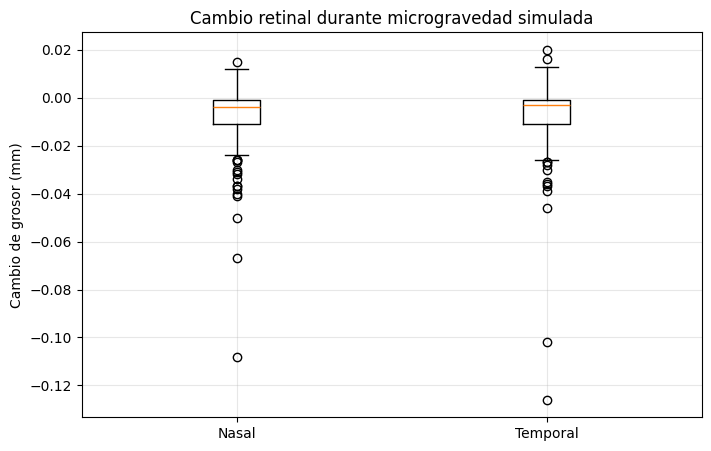

In [248]:
datos = [
    df["Cambio_Nasal_Retina"].dropna(),
    df["Cambio_Temporal_Retina"].dropna()
]

plt.figure(figsize=(8,5))
plt.boxplot(datos, labels=["Nasal", "Temporal"])
plt.ylabel("Cambio de grosor (mm)")
plt.title("Cambio retinal durante microgravedad simulada")
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_37289/657786237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["Nasal", "Temporal"])


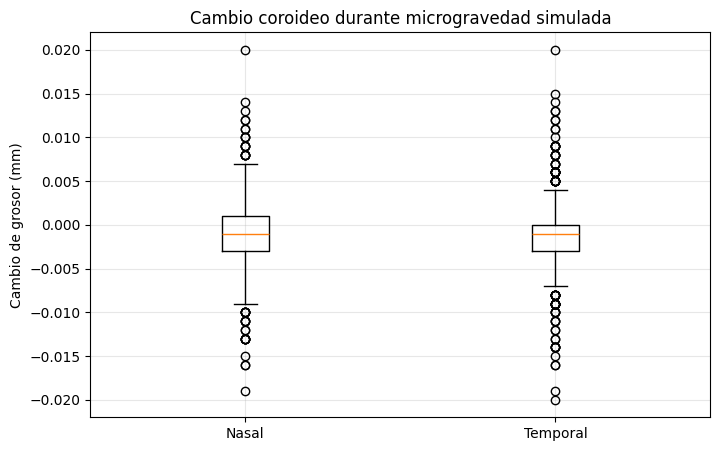

In [249]:
plt.figure(figsize=(8,5))

datos = [
    df["Cambio_Nasal_Coroides"].dropna(),
    df["Cambio_Temporal_Coroides"].dropna()
]

plt.boxplot(datos, labels=["Nasal", "Temporal"])
plt.ylabel("Cambio de grosor (mm)")
plt.title("Cambio coroideo durante microgravedad simulada")
plt.grid(True, alpha=0.3)
plt.show()

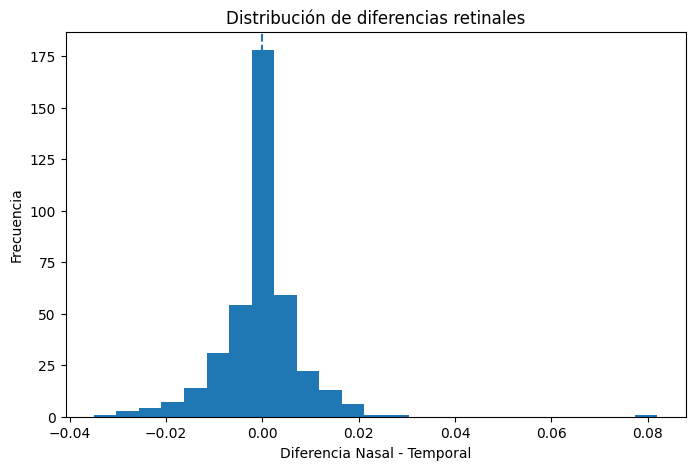

In [250]:
plt.figure(figsize=(8,5))

plt.hist(df["Dif_Retina"].dropna(), bins=25)

plt.axvline(0, linestyle="--")

plt.xlabel("Diferencia Nasal - Temporal")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias retinales")

plt.show()

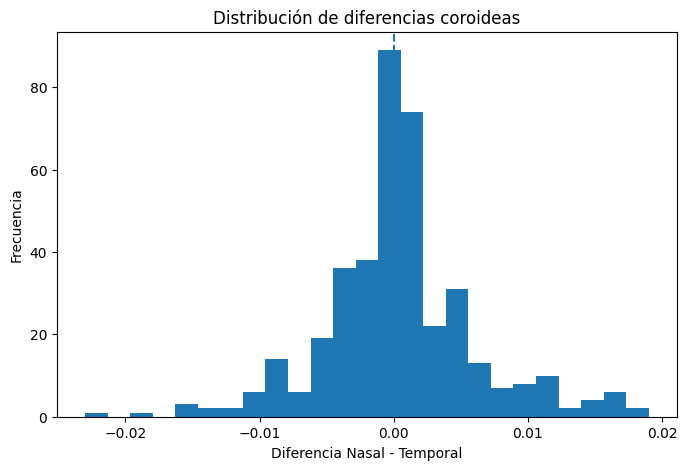

In [251]:
plt.figure(figsize=(8,5))

plt.hist(df["Dif_Coroides"].dropna(), bins=25)

plt.axvline(0, linestyle="--")

plt.xlabel("Diferencia Nasal - Temporal")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias coroideas")

plt.show()

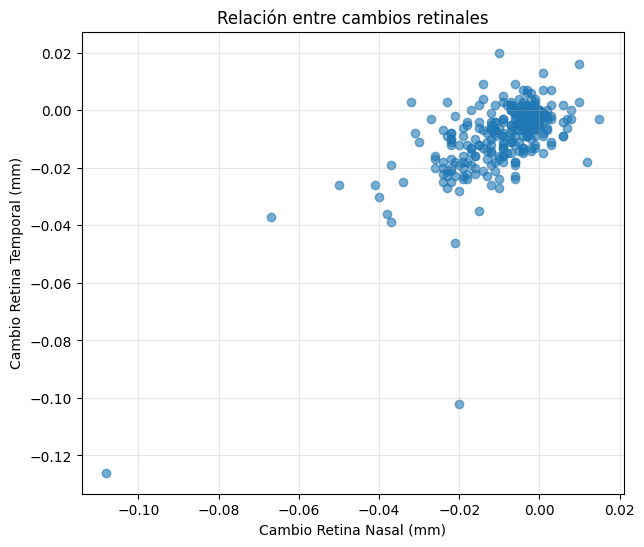

In [252]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["Cambio_Nasal_Retina"],
    df["Cambio_Temporal_Retina"],
    alpha=0.6
)

plt.xlabel("Cambio Retina Nasal (mm)")
plt.ylabel("Cambio Retina Temporal (mm)")
plt.title("Relación entre cambios retinales")

plt.grid(True, alpha=0.3)
plt.show()

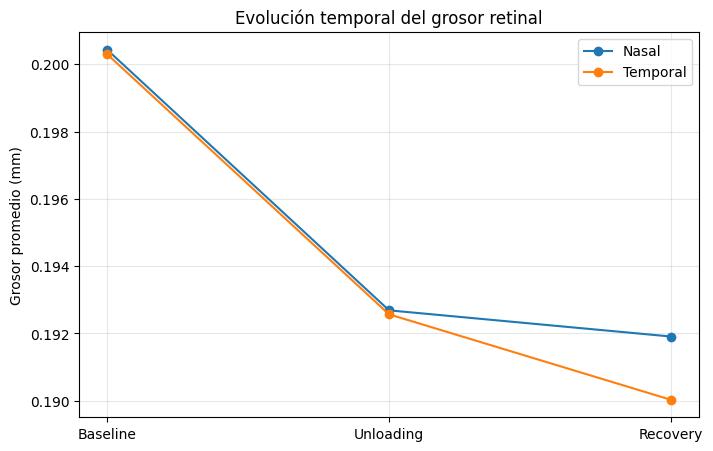

In [253]:
import matplotlib.pyplot as plt

etapas = ["Baseline", "Unloading", "Recovery"]

nasal = [
    df["Baseline _Nasal_Total_Retinal_Thickness_millimeter"].mean(),
    df["End_of_Hindlimb_Unloading_Nasal_Total_Retinal_Thickness_millimeter"].mean(),
    df["End_of_Recovery_Nasal_Total_Retinal_Thickness_millimeter"].mean()
]

temporal = [
    df["Baseline _Temporal_Total_Retinal_Thickness_millimeter"].mean(),
    df["End_of_Hindlimb_Unloading_Temporal_Total_Retinal_Thickness_millimeter"].mean(),
    df["End_of_Recovery_Temporal_Total_Retinal_Thickness_millimeter"].mean()
]

plt.figure(figsize=(8,5))

plt.plot(etapas, nasal, marker="o", label="Nasal")
plt.plot(etapas, temporal, marker="o", label="Temporal")

plt.ylabel("Grosor promedio (mm)")
plt.title("Evolución temporal del grosor retinal")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

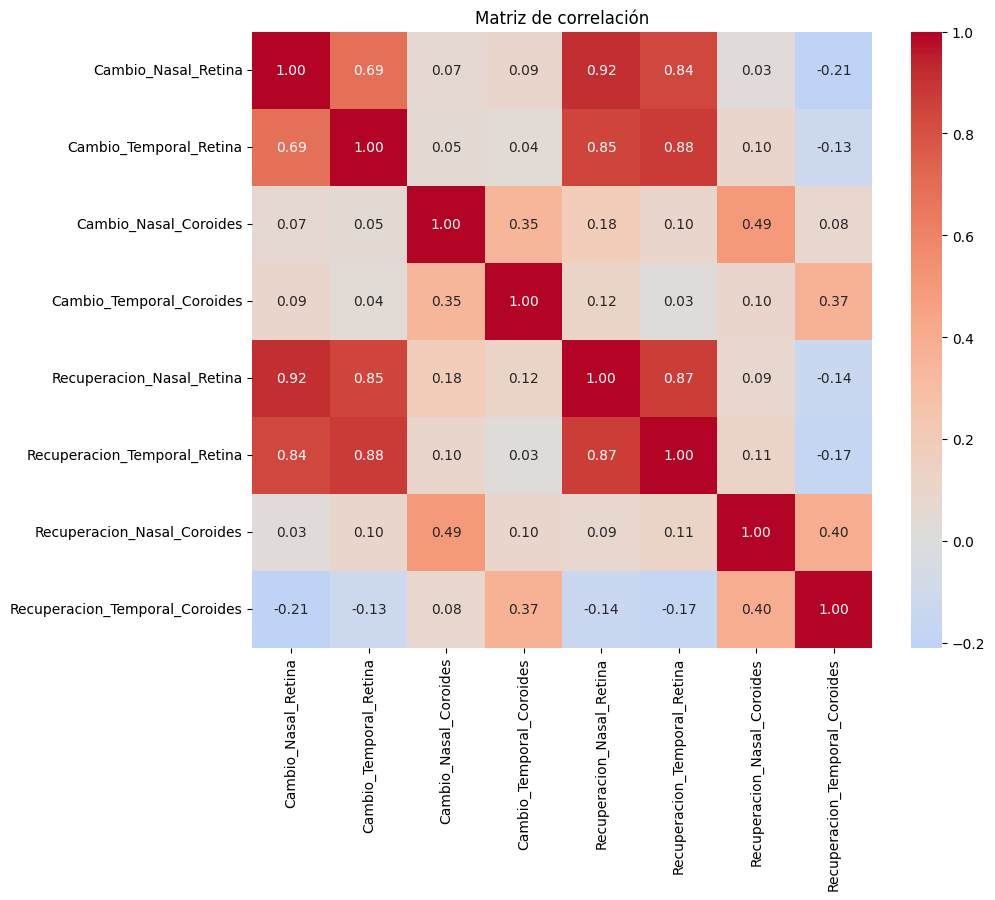

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = [
    "Cambio_Nasal_Retina",
    "Cambio_Temporal_Retina",
    "Cambio_Nasal_Coroides",
    "Cambio_Temporal_Coroides",
    "Recuperacion_Nasal_Retina",
    "Recuperacion_Temporal_Retina",
    "Recuperacion_Nasal_Coroides",
    "Recuperacion_Temporal_Coroides"
]

corr = df[variables].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()